In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Unique Customer IDs:", df['CustomerID'].nunique())
print("Unique Gender values:", df['Gender'].unique())

Unique Customer IDs: 200
Unique Gender values: ['Male' 'Female']


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
X.shape

(200, 2)

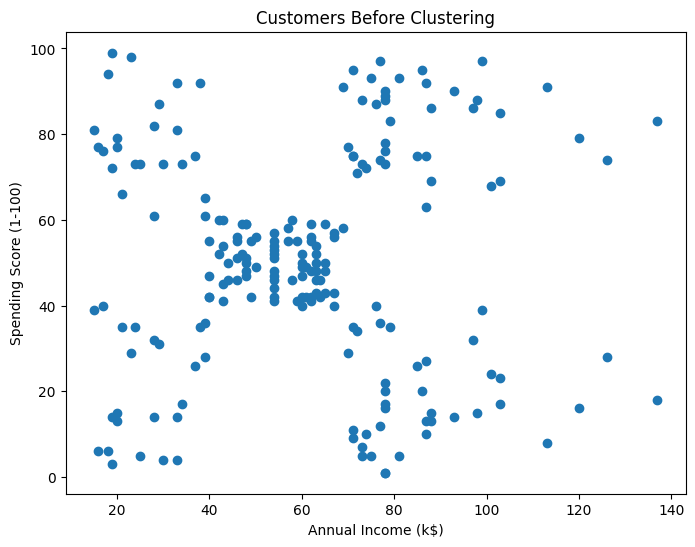

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customers Before Clustering')

plt.show()

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

wcss

[269981.28000000014,
 181363.59595959607,
 106348.37306211119,
 73679.78903948837,
 44448.45544793369,
 37233.81451071002,
 30241.34361793659,
 25036.417604033977,
 21916.79478984372,
 20072.070939404]

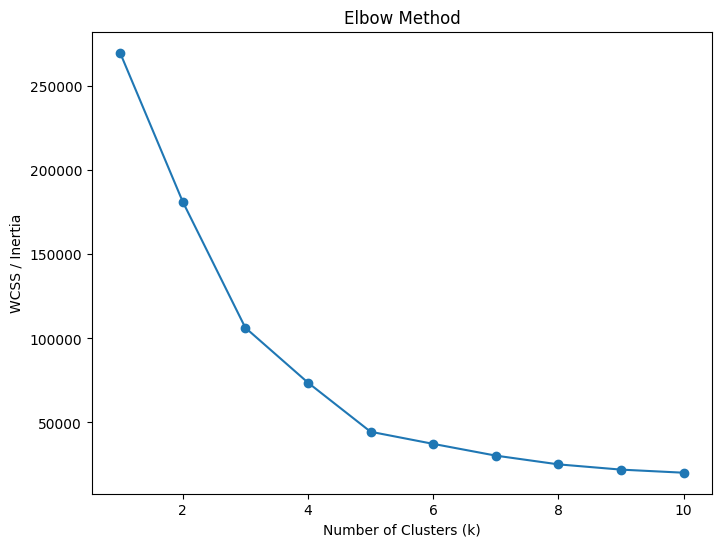

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')

plt.show()

In [ ]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

silhouette_scores

[np.float64(0.2968969162503008),
 np.float64(0.46761358158775435),
 np.float64(0.4931963109249047),
 np.float64(0.553931997444648),
 np.float64(0.53976103063432),
 np.float64(0.5288104473798049),
 np.float64(0.45481197931195283),
 np.float64(0.4561091950997367),
 np.float64(0.4410568674364981)]

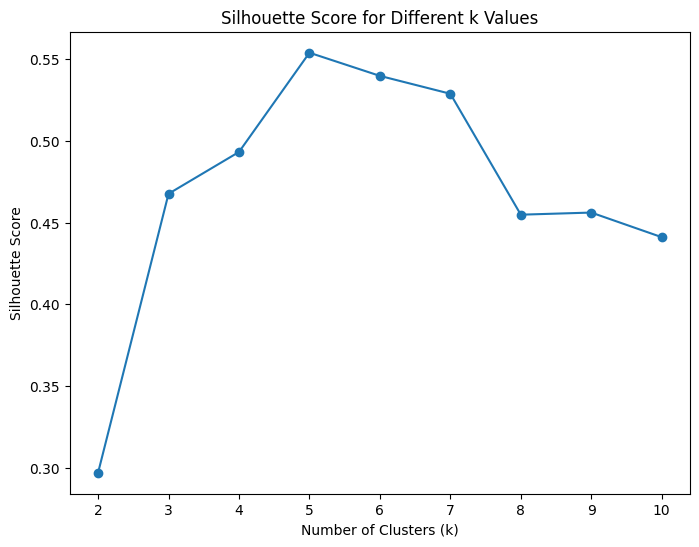

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k Values')

plt.show()

In [ ]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


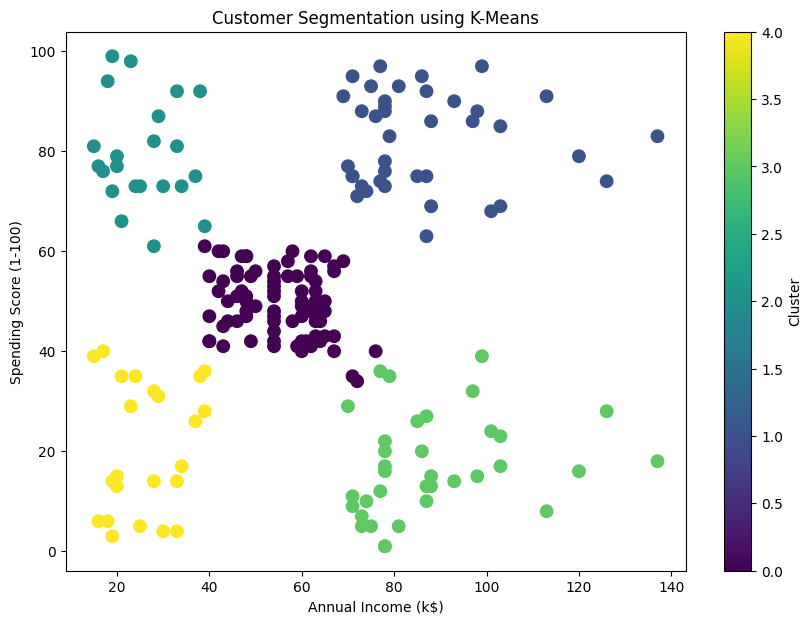

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')

plt.colorbar(label='Cluster')

plt.show()

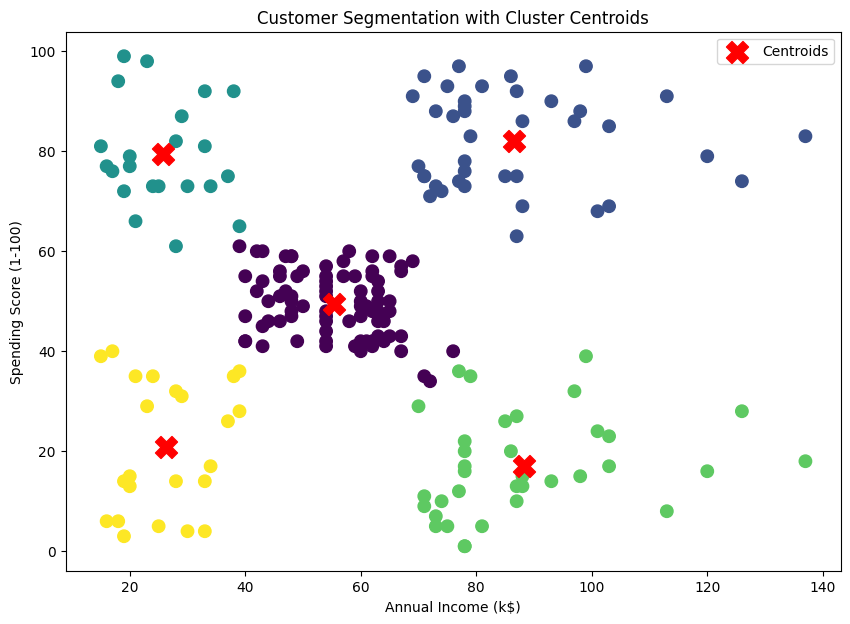

In [ ]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with Cluster Centroids')
plt.legend()

plt.show()

In [ ]:
sil_score = silhouette_score(X, df['Cluster'])

print("Silhouette Score:", sil_score)

Silhouette Score: 0.553931997444648


In [ ]:
db_score = davies_bouldin_score(X, df['Cluster'])

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 0.5725628995597082


In [ ]:
inertia = kmeans.inertia_

print("Inertia / WCSS:", inertia)

Inertia / WCSS: 44448.45544793369


In [ ]:
print("Final K-Means Evaluation")
print("------------------------")
print("Number of Clusters:", k)
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)
print("Inertia / WCSS:", inertia)

Final K-Means Evaluation
------------------------
Number of Clusters: 5
Silhouette Score: 0.553931997444648
Davies-Bouldin Index: 0.5725628995597082
Inertia / WCSS: 44448.45544793369


In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


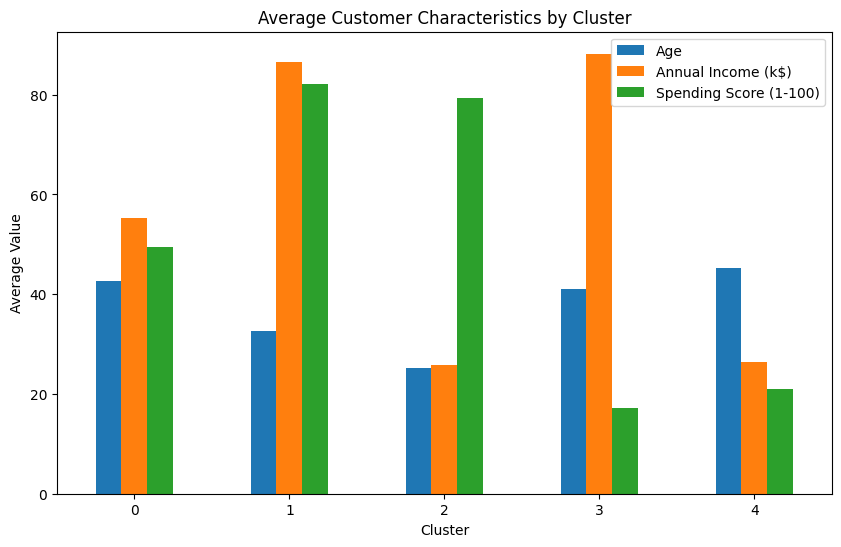

In [ ]:
cluster_summary.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.title('Average Customer Characteristics by Cluster')

plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
df.to_csv('Mall_Customers_Clustered.csv', index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.
